## ASTRO 416 FINAL PROJECT

Github Repo: https://github.com/e-gavril/asteriod-knn-classification

### INTRODUCTION

If we shine a light on an object, a certain amount of light will be reflected back at us. The amount of reflected light depends on what the object is made of. For example, a piece of wood will reflect less light than a piece of metal. Thus, the reflectance of an object can be used to determine an object's composition. 

This idea can also be applied to asteroids. Asteroids, while small, can reflect some sunlight back at us. If we measure the reflectance spectra of this asteroid, we can infer what the asteroid is made of without having to travel to it. This data is vital in understanding the compositions of asteroid populations in our Solar System, which can be used by many areas from planetary formation research to future mining operations. 

During its run, the Gaia mission captured the spectra of over 90,000 asteroids. It is amazing how large the data set is, but the idea of classifying all of these spectra is a daunting and tedious task. I attempted this in a previous project, where I took 100 asteroids and classified them by eye. This small dataset took me two weeks to classify by myself, so a data set that is 900 times larger would require a lot of time and manpower to sift through. The goal of this project is to streamline this task using machine learning. If the process is automated, spectra can be classified at much larger speeds, allowing us to get geological statistics at a much smaller cost. 

I used two datasets for this project. The first one is taken from DeMeo et. al. 2009, which defines the Bus-DeMeo asteroid taxonomical system. It is one of multiple asteroid taxonomical systems, but I chose this one because it is the most recent one and I have seen it mentioned in a few recent astronomical papers on asteroids. I also have never worked with this specific system and wanted to familiarize myself. This system is defined by 371 asteroid spectra measured from 0.45 micrometers to 2.45 micrometers with 41 seperate measurements. The paper defines 27 classes and assigns most of them an average spectra. The second dataset is taken from the Gaia database. As mentioned previously, it contains spectra for 90,000 asteroids with spectral values at 15 wavelengths ranging from 0.374 micrometers to 1.034 micrometers.

One big drawback of using these two datasets is that they do not cover the same wavelength range. The Bus-DeMeo classification spectra have a wider range of wavelengths than the Gaia spectra. Additionally, the wavelengths that Gaia does have don't exactly match the DeMeo wavelengths. As a result, I had to interpolate reflectance values from Gaia data using wavelengths used in the Bus-DeMeo system so that they would match. Considering this and the fact that the DeMeo data was scattered all over the archival page, there was a lot of effort put into constructing data frames that could be used for training and testing models. Further discussion on the datasets is covered throughout the notebook. 

### APPROACH

For this project, I used the kNN classification model. For context, this model classifies instances based on the classification of the k nearest points in a feature space, with k being some interger. The classification of the input is the class that the majority of the k nearest neighbors have. 
I believe that in the multi-dimensional feature space, similar spectral types will cluster around each other. Thus, a spectral type of an unclassified asteroid can be determined by what the majority of asteroids close to it have. For the initial approach, I used default hyperparameters for this model but moved on to hyperparameter tuning after determining benchmark metrics. 

No matter the data set, the spectral values are going to be the features, while the spectral type is going to be the target. I used the Bus-DeMeo dataset mostly for training, while the Gaia dataset is only for testing. I did an inital run with only the Bus-DeMeo data split into training and testing datasets. Afterwards, I used the whole Bus-DeMeo dataset as the training set, and a subset of the Gaia data for testing.

I tested the effectivness of the model using the accuracy metric. Considering that I want to see how many correct classifications the model made, I did not feel like other metrics, such as precision and recall, would be very helpful in this regard. As a side note, I decided not to use a confusion matrix for this project. I made this decision because I have too many spectral types to arrange into a easily understandable matrix. I believe that it would not bring much insight on the problem at hand. 

### INITIAL RESULTS

In [1]:
#loading in packages
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import xml.etree.ElementTree as ET
from astropy.table import Table as tb
from sklearn import preprocessing


from sklearn import neighbors
from sklearn import metrics
from sklearn import model_selection
import sklearn.preprocessing

from sklearn.model_selection import cross_validate
from sklearn.model_selection import StratifiedKFold

file_path = 'C:/Users/moons/Desktop/WN2025/astro416/416-final-project/'

#### **Organizing the Data**

I put all the asteroid types in a Pandas column. DeMeo et. al. 2009 has a larger list of spectral types, which include spectral types modified with a 'w' suffix. DeMeo et. al. 2009 describes these asteroids as having a higher slope than their original counterparts, which is caused by space weathering. Unfortunately, these asteroid types don't have mean spectra in the paper's data folder, so I converted each spectral type with the 'w' modification to its original type for now. 

In [2]:
#all the asteroid types put into a column, not including the 'w' modification asteroids
SpT = np.array(['A', 'B', 'C', 'Cb', 'Cg', 'Cgh', 'Ch', 'D', 'K', 'L', 'O', 'Q', 'R', 'S', 'Sa', 'Sq', 'Sr', 'Sv', 'T', 'V', 'X', 'Xc', 'Xe', 'Xk'])
SpT_col = pd.Series(SpT)

The mean spectra is stored in the meanspectra.tab document. It contains the mean reflectance spectra, with its errors, at each wavelength. The columns are not labeled, but there is a guide in the paper's datafile, which I use to further shape this dataframe. This is it's contents. 

In [4]:
spec_data = pd.read_csv('C:/Users/moons/Desktop/WN2025/astro416/416-final-project/meanspectra.tab', delim_whitespace=True, header = None, index_col = 0)
spec_data

C:\Users\moons\AppData\Local\Temp\ipykernel_4408\889920142.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  spec_data = pd.read_csv('C:/Users/moons/Desktop/WN2025/astro416/416-final-project/meanspectra.tab', delim_whitespace=True, header = None, index_col = 0)


,1,2,3,4,5,6,7,8,9,10,...,39,40,41,42,43,44,45,46,47,48
0,,,,,,,,,,,,,,,,,,,,,
0.45,0.741,0.034,0.978,0.014,0.965,0.022,1.009,0.015,0.901,-0.999,...,0.811,0.051,0.952,0.026,0.937,0.029,0.912,0.032,0.938,0.021
0.50,0.870,0.018,0.989,0.011,0.985,0.010,1.004,0.007,0.957,-0.999,...,0.908,0.025,0.980,0.013,0.973,0.009,0.948,0.033,0.971,0.010
0.55,1.000,0.000,1.000,0.000,1.000,0.000,1.000,0.000,1.000,-0.999,...,1.000,0.000,1.000,0.000,1.000,0.000,1.010,0.024,1.000,0.000
0.60,1.105,0.013,1.004,0.017,1.007,0.010,0.998,0.006,1.025,-0.999,...,1.077,0.022,1.014,0.006,1.020,0.005,1.052,0.028,1.023,0.012
0.65,1.206,0.025,1.002,0.027,1.012,0.015,1.002,0.008,1.034,-0.999,...,1.150,0.040,1.031,0.009,1.039,0.007,1.084,0.037,1.045,0.021
0.70,1.291,0.029,0.995,0.035,1.014,0.018,1.007,0.005,1.032,-0.999,...,1.212,0.053,1.050,0.013,1.058,0.006,1.107,0.039,1.064,0.027
0.75,1.295,0.027,0.983,0.045,1.014,0.019,1.016,0.005,1.026,-0.999,...,1.204,0.059,1.072,0.017,1.072,0.007,1.116,0.037,1.076,0.030
0.80,1.230,0.037,0.970,0.056,1.012,0.020,1.020,0.011,1.019,-0.999,...,1.060,0.079,1.087,0.025,1.081,0.007,1.116,0.037,1.078,0.031
0.85,1.179,0.044,0.955,0.066,1.009,0.024,1.022,0.020,1.013,-0.999,...,0.878,0.096,1.100,0.031,1.087,0.008,1.115,0.042,1.077,0.035


I modified the spec_data data frame so that there is no columns with error data, the wavelengths are the column names, and the index is the asteroid type.

In [5]:
#dropping error columns based on the guide in the data file
spec_data = spec_data.drop([2,4,6,8,10,12,14,16,18,20,22,24,26,28,30,32,34,36,38,40,42,44,46,48], axis = 1)

#setting the wavelengths as column names
spec_data = spec_data.transpose()
spec_data = spec_data.reset_index(drop = True)

#assigning the row names as the name of the asteroid
spec_data = spec_data.assign(SpT=SpT_col)
spec_data = spec_data.set_index('SpT')

In [6]:
#final result
spec_data

,0.45,0.50,0.55,0.60,0.65,0.70,0.75,0.80,0.85,0.90,...,2.00,2.05,2.10,2.15,2.20,2.25,2.30,2.35,2.40,2.45
SpT,,,,,,,,,,,,,,,,,,,,,
A,0.741,0.870,1.00,1.105,1.206,1.291,1.295,1.230,1.179,1.142,...,2.123,2.131,2.143,2.157,2.170,2.184,2.196,2.207,2.217,2.228
B,0.978,0.989,1.00,1.004,1.002,0.995,0.983,0.970,0.955,0.940,...,0.840,0.837,0.834,0.831,0.828,0.825,0.820,0.814,0.808,0.803
C,0.965,0.985,1.00,1.007,1.012,1.014,1.014,1.012,1.009,1.005,...,1.148,1.158,1.170,1.180,1.188,1.196,1.202,1.208,1.214,1.220
Cb,1.009,1.004,1.00,0.998,1.002,1.007,1.016,1.020,1.022,1.024,...,1.197,1.206,1.216,1.227,1.236,1.246,1.255,1.264,1.273,1.282
Cg,0.901,0.957,1.00,1.025,1.034,1.032,1.026,1.019,1.013,1.009,...,1.146,1.153,1.161,1.168,1.173,1.176,1.178,1.182,1.187,1.192
Cgh,0.906,0.961,1.00,1.010,1.005,0.998,0.999,1.010,1.018,1.023,...,1.167,1.169,1.170,1.170,1.169,1.165,1.160,1.157,1.156,1.153
Ch,0.961,0.987,1.00,0.993,0.982,0.976,0.979,0.988,0.992,0.993,...,1.097,1.099,1.102,1.105,1.106,1.107,1.106,1.106,1.108,1.108
D,0.904,0.953,1.00,1.042,1.086,1.129,1.169,1.197,1.234,1.279,...,1.968,1.987,2.007,2.027,2.044,2.062,2.078,2.093,2.109,2.122
K,0.883,0.944,1.00,1.044,1.085,1.118,1.132,1.114,1.088,1.077,...,1.216,1.218,1.221,1.223,1.224,1.226,1.228,1.229,1.232,1.233


In [7]:
#putting the wvls in a separate array for later use
wvls = spec_data.columns.values

After finishing the dataframe that stores the mean spectra for each spectral type, I constructed a data frame where I assigned each asteroid in their original data set a mean spectra based on the designated spectral type. The names of the asteroids and their spectral type are stored in a seperate .tab file. It includes the name of the asteroid (split into two columns depending on the type of name), the spectral type, and two extra columns that they do not explain. I modify this data frame to extract only the information I need. 

In [8]:
ast_labels = pd.read_csv('C:/Users/moons/Desktop/WN2025/astro416/416-final-project/demeotax.tab', delim_whitespace=True, header=None, index_col = 0)
ast_labels

C:\Users\moons\AppData\Local\Temp\ipykernel_4408\549936285.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  ast_labels = pd.read_csv('C:/Users/moons/Desktop/WN2025/astro416/416-final-project/demeotax.tab', delim_whitespace=True, header=None, index_col = 0)


,1,2,3,4,5
0,,,,,
1,Ceres,-,C,2005-05-19,a
2,Pallas,-,B,2001-03-29,a
3,Juno,-,Sq,2003-03-17,a
4,Vesta,-,V,2000-10-09,a
5,Astraea,-,S,2004-02-20,a
...,...,...,...,...,...
0,-,2000_PG3,D,2000-09-04,d
0,-,2001_TX16,X,2002-03-15,d
0,-,2001_XN254,S,2002-04-14,d


In [9]:
#dropping the columns 4 and 5 since I do not need them
ast_labels = ast_labels.drop([4,5], axis=1)
ast_labels = ast_labels.reset_index(drop = True)

In [10]:
#extracting the names so that I can combine them into one
#asteroids have a name either in column 1 or 2, which I confirmed by glancing at the data file on their data archive

#array to store the names
names = np.array([])

#listing through all asteroids
for i in range(len(ast_labels[1])):
    #storing both the name in column 1 and 2, there is no real siginifacance for calling a common name or not
    common_names = ast_labels[1]
    other_names = ast_labels[2]

    #if the 'common' name is non-existant, we add the other name to names array
    #other wise, the common name is stored
    if common_names[i] == '-':
        names = np.append(names, other_names[i])
    else: 
        names = np.append(names, common_names[i])

#converting the names array into a pandas column
names = pd.Series(names)

#storing all the asteroid types in a temporary array because I will modify it in the next cell
ast_types_temp = ast_labels[3]

In [11]:
#I need to get rid of all the asteroid types with the 'w' suffix, so I will make a final ast_types array
ast_types = np.array([])

for i in range(len(ast_types_temp)):
    
    #storing asteroid type
    asteroid = ast_types_temp[i]

    #if the asteroid is any of these types, it will be changed to its unmodified version
    if asteroid == 'Sw': 
        asteroid = 'S'
    if asteroid == 'Sqw': 
        asteroid = 'Sq'
    if asteroid == 'Vw': 
        asteroid = 'V'
    if asteroid == 'Srw':
        asteroid = 'Sr'
    if asteroid == 'Svw':
        asteroid = 'Sv'

    #stored in the final array
    ast_types = np.append(ast_types, asteroid)

In [12]:
#making an empty 2D array that will store the spectra for each asteroid
data_full = np.empty(shape=(371,41))

#loop goes through all rows of large 2D array
for i in range(371): 
    #store the asteroid type
    asteroid = ast_types[i] 

    #add the mean spectra of that asteroid type to array
    data_full[i, :] = spec_data.loc[asteroid, :].values

In [13]:
#convert to dataframe
all_spectra = pd.DataFrame(data = data_full)

In [14]:
#assign the wavelengths to the columns
all_spectra.columns = wvls

#insert the spectral type and name at the beginning
all_spectra.insert(loc = 0, column = 'SpT', value =  ast_types)
all_spectra.insert(loc = 0, column = 'Name', value =  names)

The final data set contains the names of the asteroids, their spectral types, and 41 columns of spectral values from 0.45 micrometers to 2.45 micrometers for each asteroid. There are 371 asteroids total.

In [15]:
all_spectra

,Name,SpT,0.45,0.5,0.55,0.6,0.65,0.7,0.75,0.8,...,2.0,2.05,2.1,2.15,2.2,2.25,2.3,2.35,2.4,2.45
0,Ceres,C,0.965,0.985,1.0,1.007,1.012,1.014,1.014,1.012,...,1.148,1.158,1.170,1.180,1.188,1.196,1.202,1.208,1.214,1.220
1,Pallas,B,0.978,0.989,1.0,1.004,1.002,0.995,0.983,0.970,...,0.840,0.837,0.834,0.831,0.828,0.825,0.820,0.814,0.808,0.803
2,Juno,Sq,0.846,0.928,1.0,1.057,1.109,1.148,1.152,1.106,...,1.297,1.303,1.315,1.328,1.337,1.346,1.353,1.360,1.367,1.373
3,Vesta,V,0.811,0.908,1.0,1.077,1.150,1.212,1.204,1.060,...,0.997,1.029,1.078,1.142,1.212,1.282,1.348,1.412,1.474,1.527
4,Astraea,S,0.839,0.922,1.0,1.063,1.123,1.173,1.193,1.162,...,1.333,1.341,1.353,1.365,1.373,1.380,1.385,1.390,1.396,1.400
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
366,2000_PG3,D,0.904,0.953,1.0,1.042,1.086,1.129,1.169,1.197,...,1.968,1.987,2.007,2.027,2.044,2.062,2.078,2.093,2.109,2.122
367,2001_TX16,X,0.952,0.980,1.0,1.014,1.031,1.050,1.072,1.087,...,1.415,1.425,1.437,1.449,1.460,1.473,1.484,1.493,1.501,1.506
368,2001_XN254,S,0.839,0.922,1.0,1.063,1.123,1.173,1.193,1.162,...,1.333,1.341,1.353,1.365,1.373,1.380,1.385,1.390,1.396,1.400
369,2002_AA,S,0.839,0.922,1.0,1.063,1.123,1.173,1.193,1.162,...,1.333,1.341,1.353,1.365,1.373,1.380,1.385,1.390,1.396,1.400


For curiosity, here is the distribution of types. I am predicting it will be better at identifying asteroids with more samples (such as V and S type asteroids), than those with smaller samples (such as Cg and Sa asteroids). 

Text(0.5, 1.0, 'Asteroid Type Distribution')

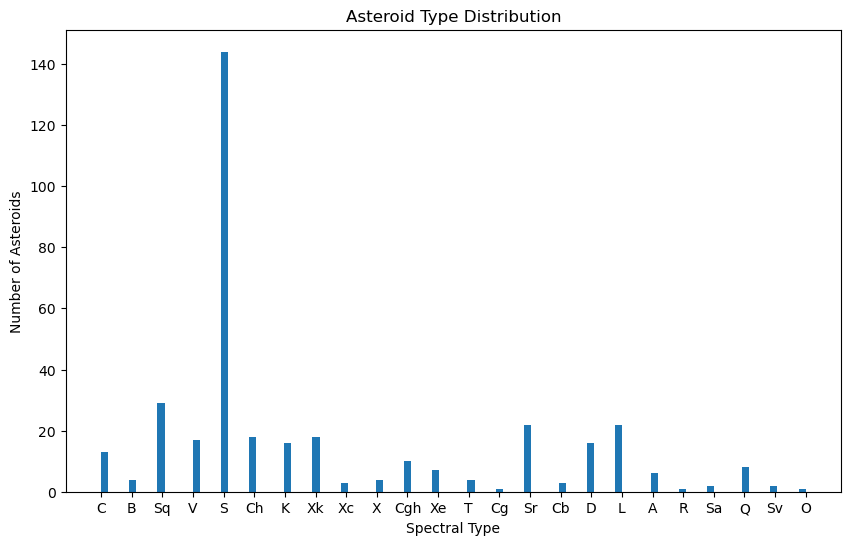

In [16]:
plt.figure(figsize=(10,6))
plt.hist(all_spectra['SpT'], bins = 100)
plt.xlabel('Spectral Type') 
plt.ylabel('Number of Asteroids')
plt.title('Asteroid Type Distribution')

#### **Training and Testing the DeMeo Dataset with kNN model**

##### **Spliting the Dataset**

In [17]:
#dropping the name column
LearningSet = all_spectra.drop(all_spectra.columns[0], axis=1) 

#targets are the spectral types
targets = LearningSet['SpT']

#using all of the 41 spectral values as the features
final_features = LearningSet.drop(LearningSet.columns[0], axis=1) 

In [18]:
#using model_selection for the train/test split
Xtrain, Xtest, ytrain, ytest = model_selection.train_test_split(final_features, targets, random_state=2)

In [19]:
#percentages
per_train = len(Xtrain)/ (len(Xtrain) + len(Xtest))
per_test = len(Xtest)/ (len(Xtrain) + len(Xtest))

print('Training/Test Split', len(Xtrain), '/', len(Xtest))
print('Training percentage:', per_train)
print('Test percentage:', per_test)

Training/Test Split 278 / 93
Training percentage: 0.7493261455525606
Test percentage: 0.25067385444743934


##### **Training the model**

In [20]:
#using default hyperparmeters for the first few runs
kNN_model = neighbors.KNeighborsClassifier(n_neighbors = 5)

In [21]:
kNN_model.fit(Xtrain, ytrain) 

KNeighborsClassifier()

##### **Metrics**

As described previously, I will be using accuracy to asses the effectiveness of the model.

In [22]:
print('Training Accuracy:', np.round(metrics.accuracy_score(ytrain, kNN_model.predict(Xtrain)), 5))
print('Testing Accracy:', np.round(metrics.accuracy_score(ytest, kNN_model.predict(Xtest)),5))

Training Accuracy: 0.97842
Testing Accracy: 0.88172


In [23]:
#I decided to also do cross-validation on this model

#using standard KFold, not stratified as it didn't work for this data set
cv = model_selection.KFold(shuffle = True, n_splits = 5, random_state=5)

#running cross-validation, with accuracy scoring metric
l_benchmark_lim = cross_validate(kNN_model, final_features, targets, cv = cv, return_train_score = True, scoring = 'accuracy')

print("Training score: {} +/- {}".format(
    np.round(l_benchmark_lim['train_score'].mean(),3), np.round(l_benchmark_lim['train_score'].std(), 3)))

print("Testing score: {} +/- {}".format(
    np.round(l_benchmark_lim['test_score'].mean(),3), np.round(l_benchmark_lim['test_score'].std(), 3)))


Training score: 0.975 +/- 0.005
Testing score: 0.938 +/- 0.052


The scores are surprisingly good, which I thought this point stemmed from the fact that I had many features. But for this project to work, I needed to cut some of these wavelengths off as the Gaia asteroid spectra only goes up to about 1.0 micrometer. So for my next test, I cut off spectral values at wavelengths above 1.0 and re-ran the model.

#### **Making the Cut**

In [24]:
#dropping all the extra features
final_features_cut = LearningSet.drop(LearningSet.columns[13:42], axis = 1)

#the new data set with less wavelengths
final_features_cut

,SpT,0.45,0.5,0.55,0.6,0.65,0.7,0.75,0.8,0.85,0.9,0.95,1.0
0,C,0.965,0.985,1.0,1.007,1.012,1.014,1.014,1.012,1.009,1.005,1.003,1.004
1,B,0.978,0.989,1.0,1.004,1.002,0.995,0.983,0.970,0.955,0.940,0.930,0.921
2,Sq,0.846,0.928,1.0,1.057,1.109,1.148,1.152,1.106,1.048,1.008,0.998,1.005
3,V,0.811,0.908,1.0,1.077,1.150,1.212,1.204,1.060,0.878,0.764,0.771,0.911
4,S,0.839,0.922,1.0,1.063,1.123,1.173,1.193,1.162,1.110,1.079,1.086,1.118
...,...,...,...,...,...,...,...,...,...,...,...,...,...
366,D,0.904,0.953,1.0,1.042,1.086,1.129,1.169,1.197,1.234,1.279,1.327,1.376
367,X,0.952,0.980,1.0,1.014,1.031,1.050,1.072,1.087,1.100,1.114,1.130,1.152
368,S,0.839,0.922,1.0,1.063,1.123,1.173,1.193,1.162,1.110,1.079,1.086,1.118
369,S,0.839,0.922,1.0,1.063,1.123,1.173,1.193,1.162,1.110,1.079,1.086,1.118


In [25]:
#dropping the spectral type classifications
final_features_cut = final_features_cut.drop(final_features_cut.columns[0], axis=1) 

In [26]:
#splitting data
Xtrain_c, Xtest_c, ytrain_c, ytest_c = model_selection.train_test_split(final_features_cut, targets, random_state=3)

per_train = len(Xtrain_c)/ (len(Xtrain_c) + len(Xtest_c))
per_test = len(Xtest_c)/ (len(Xtrain_c) + len(Xtest_c))

print('Training/Test Split', len(Xtrain_c), '/', len(Xtest_c))
print('Training percentage:', per_train)
print('Test percentage:', per_test)

Training/Test Split 278 / 93
Training percentage: 0.7493261455525606
Test percentage: 0.25067385444743934


In [27]:
#training and testing
kNN_model_cut = neighbors.KNeighborsClassifier(n_neighbors = 5)
kNN_model_cut.fit(Xtrain_c, ytrain_c) 

KNeighborsClassifier()

In [28]:
print('Training Accuracy:', np.round(metrics.accuracy_score(ytrain_c, kNN_model_cut.predict(Xtrain_c)), 5))
print('Testing Accracy:', np.round(metrics.accuracy_score(ytest_c, kNN_model_cut.predict(Xtest_c)),5))

Training Accuracy: 0.97122
Testing Accracy: 0.97849


In [29]:
cv = model_selection.KFold(shuffle = True, n_splits = 5, random_state=5)

l_benchmark_lim = cross_validate(kNN_model_cut, final_features_cut, targets, cv = cv, return_train_score = True, scoring = 'accuracy')

print("Training score: {} +/- {}".format(
    np.round(l_benchmark_lim['train_score'].mean(),3), np.round(l_benchmark_lim['train_score'].std(), 3)))

print("Testing score: {} +/- {}".format(
    np.round(l_benchmark_lim['test_score'].mean(),3), np.round(l_benchmark_lim['test_score'].std(), 3)))


Training score: 0.975 +/- 0.008
Testing score: 0.933 +/- 0.05


After doing the cut, the model seemed to improve, not worsen. After this point, I figured that the reason why the accuracy scores were so high was because the data was 'too perfect'. Since I am assigning the same mean spectra for every asteroid of a certain type, classification becomes very easy. It probably improved because there was less factors to deal with, making classifying the spectra easier. So in order to truly test the robustness of this model, I started using Gaia data as the testing dataset. 

#### **Implementing Gaia Data**

Instead of doing a training/test split on the spectral data I constructed from DeMeo data files, I decided to use the full thing as the training data set. The test set will be Gaia spectral data of asteroids that are in both data sets. Since these asteroids have already been classified, I easily matched each Gaia spectra to its spectral type. The spectra needed to be modified before I did this though. As previously mentioned, Gaia asteroid spectra covers a smaller range of wavelengths. Additionally, the wavelengths that Gaia does cover do not match the ones covered in the DeMeo spectra. Because of this, I decided to interpolate the the Gaia spectral curve at the wavelengths of the the DeMeo data. This seems to be an accurate method, as demonstrated below with the asteroid Ceres.

In [31]:
#loading in Gaia data
asteroids_gaia = tb.read('C:/Users/moons/Desktop/FA2023/data/asteroids.fits/asteroids.fits', format='fits')

#excluding all the bad spectra
asteroids_good_flag = np.where(asteroids_gaia['reflectance_spectrum_flag'] != 2)
asteroids_good = asteroids_gaia[asteroids_good_flag]

#the smaller wavelength range
goal_wvls = np.array([0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0])

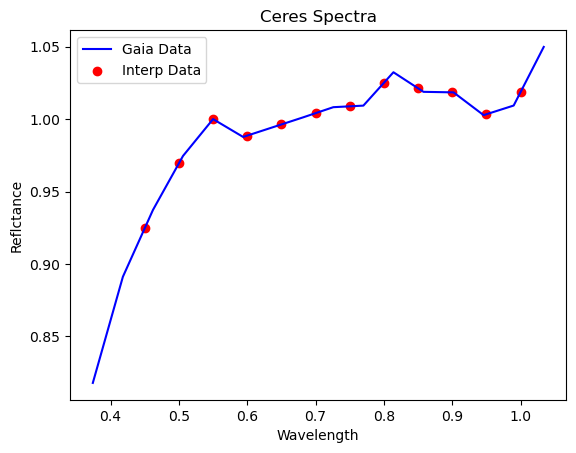

In [32]:
#example interpolation

#find all positions where spectral data for Ceres is located
ceres, = np.where(asteroids_good["denomination"]== 'ceres')

#extract wavelengths and spectral values
wvls = asteroids_good[ceres]['wavelength']/1000
spect = asteroids_good[ceres]['reflectance_spectrum']

#interpolating spectra at each wavelength
spect_ast = np.array([])
for i in range(len(goal_wvls)):
    spect_val = np.interp(goal_wvls[i], wvls, spect)
    spect_ast = np.append(spect_ast, spect_val)

plt.plot(wvls, spect, color='blue',label = "Gaia Data")
plt.scatter(goal_wvls, spect_ast, color = 'red', label = 'Interp Data') 
plt.xlabel('Wavelength') 
plt.ylabel('Reflctance')
plt.title('Ceres Spectra')
plt.legend()

From here, I implemented this strategy on all of the other asteroids. I chose 186 asteroids that exist in the DeMeo list and in the Gaia dataset, chosen randomly. I wanted to create a 2/1 split between the training and test datasets. Since 186 is around one half of 371, it will be 1/3 of the whole data set.

In [33]:
#extract the name and spectral type from the original dataset
#have to turn all the names to lower case because all names are lower case in the Gaia data set
names_gaia = all_spectra['Name'].str.lower()
spt_gaia = all_spectra['SpT'].astype(str).values

In [34]:
np.random.seed(12)

#next two lines written with help of ChatGPT
#work around for a random number generator from 0 to 371 with no repeats

#list with numbers 0 to 371 
positions = list(range(0, 371))

#shuffle the list 
np.random.shuffle(positions) 


In [35]:
#2D array for 186 asteroids with 12 spectra each
data_gaia = np.empty(shape=(186,12))

#keep record of the names used since I skip over asteroids that I can't find in the Gaia dataset
names_final = np.array([])
spt_final = np.array([])

#wanted to store the original names with capitals for double-checking purposes
names_LS_final = np.array([])


#lists through the asteroids
i = 0
#counts total asteroids add to data set
j = 0

while j < 186:
    #extract postions from random index list
    pos = positions[i]

    #extract data from Gaia dataset
    ast = np.where(asteroids_good["denomination"]== names_gaia[pos])[0]

    #if ast is empty, it means that there is no data on this asteroid, so we skip it
    if ast.size != 0:

        #extract wavelengths and spectra 
        wvls = asteroids_good[ast]['wavelength']/1000
        spect = asteroids_good[ast]['reflectance_spectrum']

        #interpolate spectra
        ast_spect_goal = np.array([])
        for k in range(len(goal_wvls)): 
            intrp_refl = np.interp(goal_wvls[k], wvls, spect)
            ast_spect_goal = np.append(ast_spect_goal, intrp_refl)

        #add final values to arrays 
        names_final = np.append(names_final, names_gaia[pos]) 
        spt_final = np.append(spt_final, spt_gaia[pos])
        names_LS_final = np.append(names_LS_final, all_spectra['Name'].iloc[pos])
        data_gaia[j, :] = ast_spect_goal

        #update number of asteroids
        j = j + 1
    i = i + 1
    


In [36]:
#convert to data frame
all_gaia_data = pd.DataFrame(data = data_gaia)

#set goal wavelengths as the column names
all_gaia_data.columns = goal_wvls

#add name and spectral type columns
all_gaia_data.insert(loc = 0, column = 'SpT', value =  spt_final)
all_gaia_data.insert(loc = 0, column = 'Name', value =  names_final)

In [37]:
#final data set
all_gaia_data

,Name,SpT,0.45,0.5,0.55,0.6,0.65,0.7,0.75,0.8,0.85,0.9,0.95,1.0
0,gyptis,C,0.942251,0.979132,1.0,1.007244,1.006151,1.016769,1.023264,1.028648,1.030160,1.034320,1.043763,1.061521
1,lecar,S,0.822199,0.894917,1.0,1.043928,1.090506,1.158607,1.205563,1.217706,1.214217,1.212069,1.157528,1.298157
2,heracles,Q,0.943799,0.960259,1.0,0.998096,1.059510,1.077129,1.070142,1.036170,1.027322,1.037578,1.145556,1.460657
3,scabiosa,Sr,0.831921,0.905671,1.0,1.051166,1.110193,1.156445,1.191598,1.191737,1.184917,1.119521,1.129577,1.150543
4,binzel,Sq,0.792876,0.873220,1.0,1.032797,1.097660,1.122972,1.162241,1.149305,1.092361,1.028022,1.018593,1.059037
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
181,herculina,S,0.825356,0.918344,1.0,1.053211,1.085594,1.125865,1.162927,1.178785,1.169653,1.148067,1.169969,1.183244
182,asahina,S,0.876546,0.886490,1.0,1.047185,1.118710,1.126625,1.149604,1.117929,1.081343,1.066517,1.191288,1.235967
183,antiope,C,0.943682,0.978600,1.0,1.001610,0.985343,0.985475,0.990607,0.991420,0.998149,0.995654,1.010107,1.040517
184,lapalma,V,0.787958,0.859881,1.0,1.096955,1.178803,1.245596,1.278794,1.190172,1.003008,0.818298,0.816936,0.872787


For a sanity check, I wanted to verify that each asteroid was properly labeled so I wrote this loop.

In [38]:
#verifying that the big loop did a good job
j = 0
for i in range(len(names_final)): 
    #pull up names from both the Gaia data frame and the original data frame
    x = np.where(all_spectra['Name'] == names_LS_final[i])[0]
    y = np.where(all_gaia_data['Name'] == names_final[i])[0] 

    #store the asteroid spectra for that asteroid
    ast_type_1 = all_spectra['SpT'].iloc[x].astype(str).values
    ast_type_2 = all_gaia_data['SpT'].iloc[y].astype(str).values

    #if they are not the same, print the name that doesn't match
    if ast_type_2 != ast_type_1:
        print(names_LS_final[i], 'does not match.') 
        #counter for alternative message
        j = j + 1
#if not detections, prints line
if j == 0: 
    print('All clear!') 
        

All clear!


#### **Training and Testing New Data**

In [39]:
#training set is the cut dataset and its spectral types
X_train = final_features_cut
y_train = targets

#test set is the Gaia data and the corresponding spectral type
X_test = all_gaia_data.drop(['Name', 'SpT'], axis = 1)
y_test = all_gaia_data['SpT']


#use basic hyperparameters again
kNN_model_wgaia = neighbors.KNeighborsClassifier(n_neighbors = 5) 
kNN_model_wgaia.fit(X_train, y_train) 

KNeighborsClassifier()

In [40]:
print('Training Accuracy:', np.round(metrics.accuracy_score(y_train, kNN_model_wgaia.predict(X_train)), 5))
print('Testing Accracy:', np.round(metrics.accuracy_score(y_test, kNN_model_wgaia.predict(X_test)),5))

Training Accuracy: 0.98652
Testing Accracy: 0.15591


These values feel more accurate, though the testing accuracy is discouragingly low. There is one more modification to the data that I did before going onto hyperparameter tuning.

**Adding More Spectral Types**

In previous attempts, I decided to toss spectral types that had a 'w' suffix. In this iteration, I add them back in. The problem is that there is no mean spectra for these types in the DeMeo paper. So I deduced them by taking the asteroids that define the class, finding the spectra for those asteroids in Gaia, and taking the average of all of them.

In [41]:
#redoing the asteroid types extraction without changing the spectral type
ast_types = np.array([])
for i in range(len(ast_types_temp)):
    asteroid = ast_types_temp[i]
    ast_types = np.append(ast_types, asteroid) 

#storing the names and spectral types in a dataframe
temp_frame = pd.DataFrame(data = names, columns = ['Name']) 
temp_frame.insert(loc = 1, column = 'SpT', value =  ast_types)


In [42]:
#extracting all the positions of asteroids of a specific spectral type
Sw_asts_pos = np.where(temp_frame['SpT'] == 'Sw')[0]
Sqw_asts_pos= np.where(temp_frame['SpT'] == 'Sqw')[0]
Vw_asts_pos = np.where(temp_frame['SpT'] == 'Vw')[0]
Srw_asts_pos = np.where(temp_frame['SpT'] == 'Srw')[0]
Svw_asts_pos = np.where(temp_frame['SpT'] == 'Svw')[0]

#extracting the names of all asteroid of a specific spectral type 
Sw_asts = temp_frame['Name'].iloc[Sw_asts_pos]
Sqw_asts = temp_frame['Name'].iloc[Sqw_asts_pos]
Vw_asts = temp_frame['Name'].iloc[Vw_asts_pos]
Srw_asts = temp_frame['Name'].iloc[Srw_asts_pos]
Svw_asts = temp_frame['Name'].iloc[Svw_asts_pos]



In [43]:
def find_avg_spect_for_type(arr):
    """
    Finds the average spectra for a collection of asteroids, specifically used for arrays made in the above cell

    Args: 
        arr (Pandas Column): list of asteroid names with the same spectral type 

    Returns:
        numpy arr: Average spectra
    """

    #there is an extra index column in all of the arrays that I need to drop
    arr = arr.reset_index().drop('index', axis = 1) 

    #intializing array to hold the average spectra
    avg_spect = np.zeros(12)
    
    #doing a total count of asteroids used for averaging later
    tot_asts = 0
    for i in range(len(arr)):
        #extract name
        name = arr['Name'].iloc[i].lower()

        #extract data from Gaia
        ast = np.where(asteroids_good["denomination"]== name)[0]

        #if there is Gaia data
        if ast.size != 0: 
            #extract the wavelengths and spectra
            wvls = asteroids_good[ast]['wavelength']/1000
            spect = asteroids_good[ast]['reflectance_spectrum']

            #interpolate each spectral value
            ast_spect_goal = np.array([])
            for k in range(len(goal_wvls)): 
                intrp_refl = np.interp(goal_wvls[k], wvls, spect)
                ast_spect_goal = np.append(ast_spect_goal, intrp_refl)

            #add to the final array
            avg_spect = avg_spect + ast_spect_goal

            #increase number of asteroids
            tot_asts = tot_asts + 1
    #calculates average
    avg_spect = avg_spect/tot_asts
    return avg_spect

In [44]:
#finding average spectra for each spectral type
Sw_avg_spect = find_avg_spect_for_type(Sw_asts)
Sqw_avg_spect = find_avg_spect_for_type(Sqw_asts)
Vw_avg_spect = find_avg_spect_for_type(Vw_asts)
Srw_avg_spect = find_avg_spect_for_type(Srw_asts)
Svw_avg_spect = find_avg_spect_for_type(Svw_asts)

After defining these average spectra, I rebuilt both the original DeMeo dataset and the Gaia dataset from scratch.

In [45]:
#quickly summarizing previously done steps
#make array with all asteroid names
SpT_new = np.array(['A', 'B', 'C', 'Cb', 'Cg', 'Cgh', 'Ch', 'D', 'K', 'L', 'O', 'Q', 'R', 'S', 'Sw', 
'Sa', 'Sq', 'Sqw', 'Sr', 'Srw', 'Sv', 'Svw' 'T', 'V', 'Vw' 'X', 'Xc', 'Xe', 'Xk'])
SpT_col_new = pd.Series(SpT_new)

In [46]:
#new 2D array, cutting straight to 12 wavelengths
data_full = np.empty(shape=(371,12))
for i in range(371): 
    #extract asteroid type
    asteroid = ast_types[i] 

    #if the asteroid is any of these spectral types, the average spectra will be inserted 
    if asteroid == 'Sw': 
        data_full[i, :] = Sw_avg_spect
    elif asteroid == 'Sqw': 
        data_full[i, :] = Sqw_avg_spect
    elif asteroid == 'Vw': 
        data_full[i, :] = Vw_avg_spect
    elif asteroid == 'Srw':
        data_full[i, :] = Srw_avg_spect
    elif asteroid == 'Svw':
        data_full[i, :] = Svw_avg_spect
    else: 
        #otherwise, pulling from DeMeo
        temp_spec = spec_data.loc[asteroid, :].values
        data_full[i, :] = temp_spec[0:12]
    
    

In [47]:
#construct new dataframe
all_spectra_new = pd.DataFrame(data = data_full)
all_spectra_new.columns = goal_wvls
all_spectra_new.insert(loc = 0, column = 'SpT', value =  ast_types)
all_spectra_new.insert(loc = 0, column = 'Name', value =  names)

In [48]:
#constructing new Gaia test set
spt_gaia = all_spectra_new['SpT'].astype(str).values

#initializing empty arrays
data_gaia = np.empty(shape=(186,12))
names_final = np.array([])
spt_final = np.array([])
names_LS_final = np.array([])


#extract the interpolated spectra 
i = 0
j = 0
while j < 186:
    pos = positions[i]
    ast = np.where(asteroids_good["denomination"]== names_gaia[pos])[0]
    if ast.size != 0:
        wvls = asteroids_good[ast]['wavelength']/1000
        spect = asteroids_good[ast]['reflectance_spectrum']

        ast_spect_goal = np.array([])
        for k in range(len(goal_wvls)): 
            intrp_refl = np.interp(goal_wvls[k], wvls, spect)
            ast_spect_goal = np.append(ast_spect_goal, intrp_refl)
        names_final = np.append(names_final, names_gaia[pos]) 
        spt_final = np.append(spt_final, spt_gaia[pos])
        names_LS_final = np.append(names_LS_final, all_spectra['Name'].iloc[pos])
        data_gaia[j, :] = ast_spect_goal
        j = j + 1
    i = i + 1

In [49]:
#setting up final data frame
all_gaia_data_new = pd.DataFrame(data = data_gaia)
all_gaia_data_new.columns = goal_wvls
all_gaia_data_new.insert(loc = 0, column = 'SpT', value =  spt_final)
all_gaia_data_new.insert(loc = 0, column = 'Name', value =  names_final)

In [50]:
#checking that the two datasets match 
j = 0
for i in range(len(names_final)): 
    x = np.where(all_spectra_new['Name'] == names_LS_final[i])[0]
    y = np.where(all_gaia_data_new['Name'] == names_final[i])[0] 
    ast_type_1 = all_spectra_new['SpT'].iloc[x].astype(str).values
    ast_type_2 = all_gaia_data_new['SpT'].iloc[y].astype(str).values
    if ast_type_2 != ast_type_1:
        print(names_LS_final[i], 'does not match.') 
        j = j + 1
if j == 0: 
    print('All clear!') 
        

All clear!


#### **Training and Testing Final Version of the Dataset**

In [51]:
X_train = all_spectra_new.drop(['Name', 'SpT'], axis = 1)
y_train = all_spectra_new['SpT']

X_test = all_gaia_data_new.drop(['Name', 'SpT'], axis = 1)
y_test = all_gaia_data_new['SpT']

#basic parameters for model
kNN_model_wgaia_new = neighbors.KNeighborsClassifier(n_neighbors = 5) 
kNN_model_wgaia_new.fit(X_train, y_train) 

KNeighborsClassifier()

In [52]:
print('Training Accuracy:', np.round(metrics.accuracy_score(y_train, kNN_model_wgaia_new.predict(X_train)), 5))
print('Testing Accracy:', np.round(metrics.accuracy_score(y_test, kNN_model_wgaia_new.predict(X_test)),5))

Training Accuracy: 0.98113
Testing Accracy: 0.19892


In the end, the training accuracy stayed roughly the same, but the testing accuracy is still very low. On the bright side, the model seems to work like a model that can be improved on instead of a perfect model for perfect data. From here, I will implement some hyperparameter tuning to see if that can improve the accuracy score. The final model and data set for this section are a good benchmark for improving upon the model in the next section. 

### FINAL RESULTS

For my final attempt to improve this model, I tried to optimize the hyperparameter. The main three parameters I changed are as follows: 

**n_neighbors**: the number of neigbors used in the classification <br>
**weights**: the amount of weight assigned to each neighbor <br>
**algorithm**: the process used to find the nearest neighbor <br>

I refrained from using the other hyperparameters described in the KNeigbors classifier as they had to do with the speed of the process and the way distance was measured (i.e. whether the model will use Manhattan distance or Euclidean distance. I thought Euclidean was better, as the distance is measured as the shortest line between the two points, so I made no changes). Additionally, I decided to scale the data as well to see if that would make a difference.

In [53]:
#scaling the data with a Standard Scaler
standard = preprocessing.StandardScaler()

standard.fit(X_train) 
stan_Xtrain = standard.transform(X_train)
stan_Xtest = standard.transform(X_test) 

In [54]:
"""
n_neighbors = any int
weights = 'uniform', 'distance'
algorithm = 'auto', 'ball_tree', 'kd_tree', 'brute’

other parameters should stay the same to give Euclidean distance measurements
numof leaves omitted for simplicity

"""
#for the n_neighbors, I also added 101 to see how the model will behave at extreme values
#considering this data set is only around 400 values, using ~100 neighbors seems impractical but I wanted to test it nonetheless
try_n_neighbors = np.array([1,3,5,7,9,11,13,15,17,21,23,25,27,29,31,33,35,37,39,41,43,45,47,49,101]) 
try_weights = np.array(['uniform', 'distance']) 
try_algorithm = np.array(['auto', 'ball_tree', 'kd_tree', 'brute']) 

In [55]:
#storing all the parameters and scores in an array so I calculate the number of rows I need
rows = len(try_n_neighbors) * len(try_weights)  * len(try_algorithm) 

#setting up the dataframe to store the parameters and scores
hyper_params_temp = np.empty(shape = (rows, 5))
hyperparams = pd.DataFrame(data = hyper_params_temp, columns = ['n', 'weights', 'algorithm', 'training accuracy', 'testing accuracy'])
hyperparams = hyperparams.astype('object')


#indicates the position of where to put results into the array
i = 0

#for every value of n, loop tries all weights and algorithms
for n in try_n_neighbors:
    for w in try_weights: 
        for a in try_algorithm: 
            #set up the model
            kNN_test_model = neighbors.KNeighborsClassifier(n_neighbors = n, weights = w, algorithm = a) 

            #train with scaled features
            kNN_test_model.fit(stan_Xtrain, y_train) 

            #calculate accuracy scores
            train_acc =  np.round(metrics.accuracy_score(y_train, kNN_test_model.predict(stan_Xtrain)), 5)
            test_acc = np.round(metrics.accuracy_score(y_test, kNN_test_model.predict(stan_Xtest)),5)

            #put results in the dataframe
            results = np.array([n, w, a, train_acc, test_acc])
            hyperparams.loc[i]  = results

            #move on to the next row
            i = i + 1
     

In [56]:
#finding the best scores with the 101 neighbors included
best_extreme = np.where(hyperparams['testing accuracy'] == np.max(hyperparams['testing accuracy']))[0]

#now excluding the 101, finding the best scores
#for some reason, all the n values were converted to strings
hyperparams_no_xtreme = hyperparams.loc[hyperparams['n'] != '101']
best = np.where(hyperparams_no_xtreme['testing accuracy'] == np.max(hyperparams_no_xtreme['testing accuracy']))[0] 

In [57]:
hyperparams_no_xtreme.loc[best]

,n,weights,algorithm,training accuracy,testing accuracy
156,41,distance,auto,1.0,0.33333
157,41,distance,ball_tree,1.0,0.33333
158,41,distance,kd_tree,1.0,0.33333
159,41,distance,brute,1.0,0.33333
164,43,distance,auto,1.0,0.33333
165,43,distance,ball_tree,1.0,0.33333
166,43,distance,kd_tree,1.0,0.33333
167,43,distance,brute,1.0,0.33333
180,47,distance,auto,1.0,0.33333
181,47,distance,ball_tree,1.0,0.33333


In [58]:
hyperparams.loc[best_extreme]

,n,weights,algorithm,training accuracy,testing accuracy
196,101,distance,auto,1.0,0.34409
197,101,distance,ball_tree,1.0,0.34409
198,101,distance,kd_tree,1.0,0.34409
199,101,distance,brute,1.0,0.34409


Out of all the models, the ones where the weights were set to distance tended to perform better than everything else, while the algorithm did not seem to matter much. The hyperparameter that seemed to have the most influence on the testing accuracy score was the number of neighbors. But even at high numbers of neighbors, the model was classifying most of the dataset incorrectly. Another concerning factor is that despite doubling the the number of neighbors from 49 to 101, the testing accuracy only improved by 1%. Considering that 101 neigbors is already an unrealistic number to use for this data set, it is concerning that a good testing accuracy score may lie above that number. As a summary, here are is a plot of the n_neigbors versus the accuracy score. 

Text(0, 0.5, 'Accuracy Score')

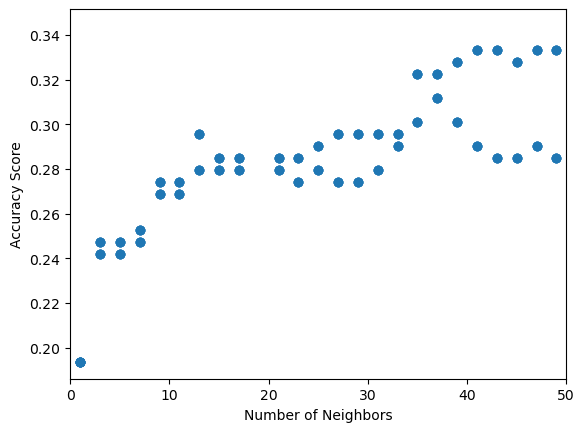

In [59]:
plt.scatter(hyperparams['n'].astype(float), hyperparams['testing accuracy'].astype(float))
plt.xlim(0,50)
plt.xlabel('Number of Neighbors')
plt.ylabel('Accuracy Score')

As a last step, I wanted to plot the best model found through the hyperparameter tuning (excluding the one with 101 neighbors)

In [60]:

#train and test model
kNN_best = neighbors.KNeighborsClassifier(n_neighbors = 49, weights = 'distance') 
kNN_best.fit(stan_Xtrain, y_train) 
y_pred = kNN_best.predict(stan_Xtest)

#determing which classification were made correctly for the histogram
same = np.where(y_test == y_pred)[0]
diff = np.where(y_test != y_pred)[0]


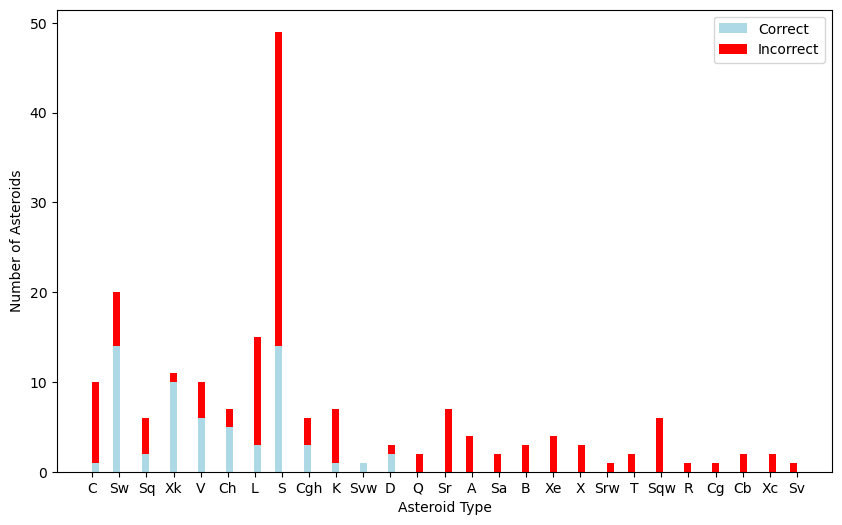

In [61]:
plt.figure(figsize=(10,6))
plt.hist([y_test[same], y_test[diff]], bins = 100, color = ['lightblue', 'red'], label = ['Correct', 'Incorrect'], stacked=True)
plt.xlabel('Asteroid Type') 
plt.ylabel('Number of Asteroids')
plt.legend()
plt.show()

Overall, most of the asteroid types were classified incorrectly. Those that had some correct classifications tended to be in groups with more samples. Most of the asteroid types that had less than ten samples were classified incorrectly. This confirms the hypothesis I had at the beginning of this project.

### REFLECTIONS

In conclusion, this attempt of optimization of asteroid spectra classification using machine learning was unsuccessful. I did not produce a model that would reliably classify spectra correctly, get it wrong around 66% of the time. There are a couple of reasons why I believe this happened. For one, maybe the fact that the model was trained on what I called 'perfect data' made it difficult for it to classify data that wasn't ideal. For future attempts, it may be best to construct a dataset of Gaia data of all the asteroids in DeMeo et.al. 2009 instead and use it for both training and testing. Another reason maybe because some classes had very few examples, so the model was not properly learn them. There are three methods that I can think of for improving this. One would be to gather more samples, which may prove tedious as it would require sifting through a lot of databases. Another method would be to train a model to generate some spectra based on the data we have to expand the learning set. Finally, it may be best to switch to anothe taxonomical system altogether. Considering there are so few examples of some types, maybe the system was just too complex. Finally, the model itself maybe the issue as well. My previous assumptions that it would be able to identify cluster in a multi-dimensional space may have been too optimisitic. This may also be complicated by the fact that not only is my original dataset very small for machine learning, it also has a lot more S types than any other types. It may be beneficial to imploy a more robust model, such as neural networks.

### AI STATEMENT

I used ChatGPT for help creating a random number generator that picks through a range of numbers a does not repeat. I was struggling to make one myself, because I though I had to use np.random.choice but I wasn't able to figure out how to implement it. It did not find a numpy.random function that could work, but found a work around by creating a list of numbers from 0 to 371 and then shuffling that list of numbers. This code is found in the **Implementing Gaia Data** section and flagged as being written by AI. For convenience, this code is also shown below, with comments. 

```python

np.random.seed(12)

#next two lines written with help of ChatGPT
#work around for a random number generator from 0 to 371 with no repeats

#list with numbers 0 to 371 
positions = list(range(0, 371))

#shuffle the list 
np.random.shuffle(positions) 

```

## CITATIONS

DeMeo et. al. 2009 <br>
Gaia Collaboration et. al. 2023